# \# Clustering
## -> KMeans Clustering

In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)

In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [3]:
# make_blobs returns the mapped y output label also -> so we don't use it
X, y = make_blobs(
    n_samples=1000,
    n_features = 2,
    centers = 4, # no. of true clusters
    random_state=42
)

<Axes: >

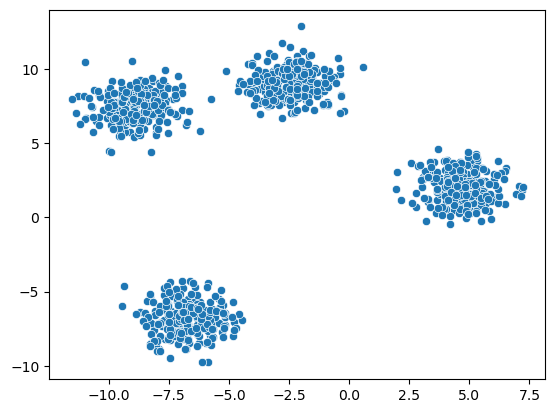

In [4]:
# visualize
sns.scatterplot(x=X[:,0], y=X[:,1])

In [5]:
# K-Means Clustering
from sklearn.cluster import KMeans

In [6]:
K = 4

kmeans = KMeans(
    n_clusters=K,
    init="k-means++", # by default
    random_state=42
)

labels = kmeans.fit_predict(X)
# labels = cluster number

<Axes: >

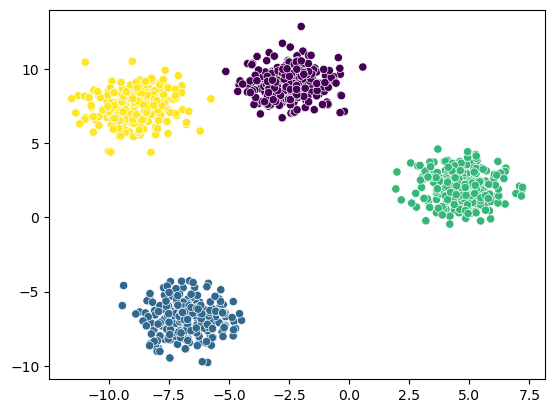

In [7]:
# visualize
sns.scatterplot(x=X[:,0], y=X[:,1], c = labels)

### Choose our K value -> elbow, silhouette score

<Axes: >

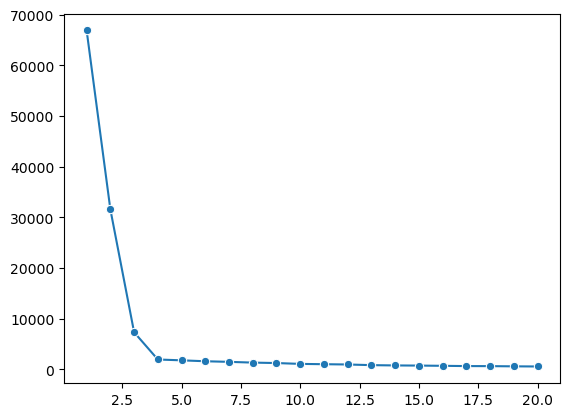

In [8]:
# Elbow Method

wcss=[]
for k in range(1,21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

# plot K vs wcss

sns.lineplot(x=range(1,21), y=wcss, marker="o")


In [9]:
# automatic way to do elbow method and find k using kneed module
!pip install kneed

In [10]:
from kneed import KneeLocator

knee = KneeLocator(range(1,21), wcss, curve = "convex", direction = "decreasing")
print("Elbow point (K) : ", knee.knee)
print("Elbow point (K) : ", knee.elbow)


Elbow point (K) :  4
Elbow point (K) :  4


## \# silhouette score

In [11]:
from sklearn.metrics import silhouette_score

ss = []

for k in range(2,21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X,labels)
    ss.append(score)

<Axes: >

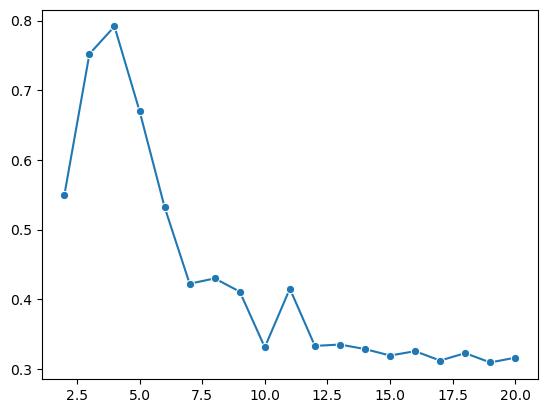

In [12]:
# plot k vs ss
sns.lineplot(x=range(2,21), y=ss, marker="o")

# \## K-Means for the Iris Dataset

In [29]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)

In [30]:
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.cluster import KMeans

In [31]:
iris = load_iris()
X = iris.data
y = iris.target

<Axes: >

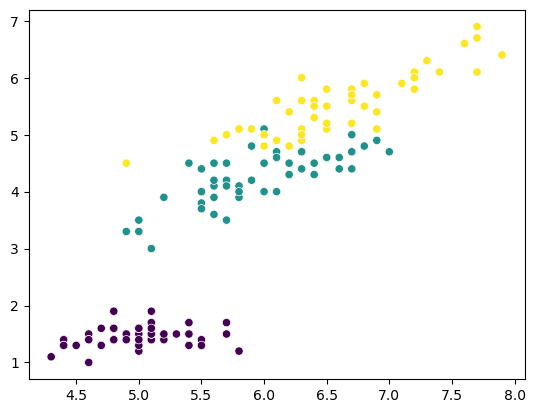

In [32]:
# visualization of 2 features only
sns.scatterplot(x=X[:,0], y=X[:,2], c= y)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [62]:
# dimensenlity reduction using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2) # n_component -> means all features reducted to 2 features
pca_data = pca.fit_transform(X_scaled)

<Axes: >

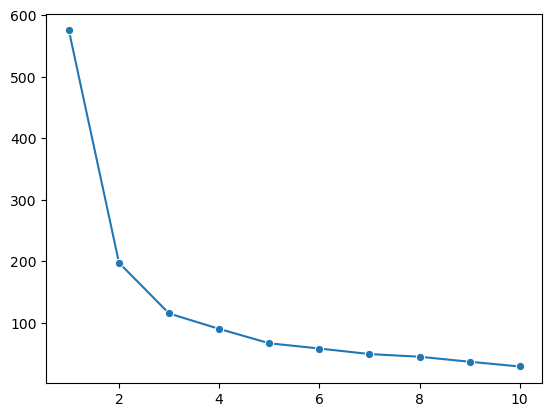

In [63]:
# elbow method
wcss = []
for k in range(1,11):
    kmeans= KMeans(n_clusters=k)
    kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)


# plot k vs wcss
sns.lineplot(x=range(1,11), y = wcss, marker="o")

<Axes: >

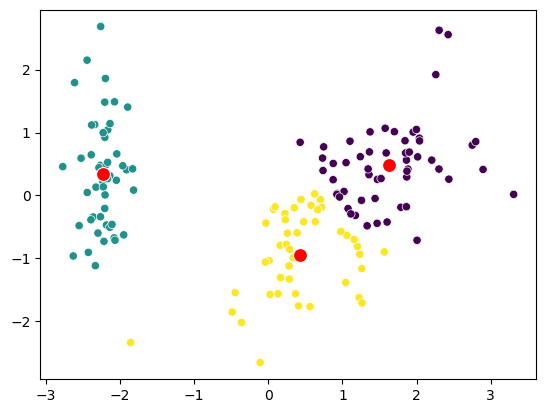

In [73]:
# optimal  k = 3
kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0], y = pca_data[:,1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y = kmeans.cluster_centers_[:,1], marker="o", c="red", s=100)